# Negative Multinomial Distribution

`NegativeMultinomial(r, p)` describes the following experiment. A jar holds marbles in several colors. Draw them out one at a time, *with* replacement, and stop as soon as you have pulled `r` marbles of one particular color -- the **stopping color**. The distribution is of **how many of each other color you drew along the way**.

For instance: a jar where half the marbles are blue, 30% are red, and 20% are green, drawing until the 3rd blue appears. How many reds and how many greens did you collect? Both answers arrive together, as a pair. Neither one has an upper limit, because an unlucky run can go on for a long time before that third blue shows up.

`p` gives the probabilities of only the colors you are counting -- here `[0.3, 0.2]` for red and green. Whatever probability is left over, `1 - sum(p)` = 0.5, belongs to the stopping color.

It is the several-colors version of the `Pascal` distribution, and the "keep drawing until" version of `Multinomial` -- we compare it to both further down.

In [1]:
from symbulate import *

## Draw a value from a negative multinomial distribution

Each draw is a vector of counts, one per counted color, in the same order as `p`.

In [2]:
NegativeMultinomial(r=3, p=[0.3, 0.2]).draw()

(1, 3)

## Theoretical mean, variance, and standard deviation

For a vector-valued distribution these return one value per counted color. The mean has a tidy form: `r * p[i] / p0`. Reading it as a rate helps -- each marble of the stopping color you wait for buys you, on average, `p[i] / p0` marbles of color `i`.

In [3]:
X = NegativeMultinomial(r=3, p=[0.3, 0.2])
X.mean(), X.var(), X.sd()

((1.7999999999999998, 1.2000000000000002),
 (2.88, 1.6800000000000002),
 (1.697056274847714, 1.2961481396815722))

In [4]:
3 * 0.3 / 0.5, 3 * 0.2 / 0.5

(1.7999999999999998, 1.2000000000000002)

## Covariance and correlation matrices

`cov()` returns the full covariance matrix, whose diagonal holds the per-color variances shown above; `corr()` rescales it into correlations between -1 and 1.

The off-diagonal entries are **positive**, which is worth pausing on -- counts in a `Multinomial` are negatively correlated. The comparison further down shows where the difference comes from.

In [5]:
X.cov()

array([[2.88, 0.72],
       [0.72, 1.68]])

In [6]:
X.corr()

array([[1.        , 0.32732684],
       [0.32732684, 1.        ]])

## Assign and simulate random variables

Unpacking gives one random variable per counted color, and `&` pairs them back up so a simulated value shows both counts at once.

In [7]:
A, B = RV(NegativeMultinomial(r=3, p=[0.3, 0.2]))
sims = (A & B).sim(10000)
sims

0,"(0, 0)"
1,"(1, 1)"
2,"(5, 2)"
3,"(0, 1)"
4,"(1, 0)"
5,"(0, 1)"
6,"(0, 0)"
7,"(0, 1)"
8,"(0, 2)"
...,...
9999,"(5, 1)"


A frequency table shows how often each pair of counts turned up. Unlike the `Multinomial`, there is no total for the counts to add up to, so the list of possible pairs never ends. The table is sorted by pair and truncated in the middle: the smallest pairs, which are also the likeliest, sit at the top, and a long thin tail runs off below.

In [8]:
sims.tabulate(normalize=True)

"(0, 0)",0.1238
"(0, 1)",0.0754
"(0, 2)",0.0309
"(0, 3)",0.01
"(0, 4)",0.0035
"(0, 5)",0.0012
"(0, 6)",0.0001
"(0, 7)",0.0002
"(1, 0)",0.1119
"(1, 1)",0.0881
"(1, 2)",0.0419


Those relative frequencies should sit close to the theoretical probabilities.

In [9]:
[round(X.pdf([a, b]), 4) for a, b in [(0, 0), (0, 1), (1, 0), (1, 1)]]

[0.125, 0.075, 0.1125, 0.09]

There is no `cdf`, for the same reason none of the other multivariate distributions have one: there is no natural way to put the vectors it produces in order.

## Waiting for more stops collects more of everything

Raising `r` means drawing for longer, so more of every color comes out along the way. Each curve below is the simulated red count for a larger `r`, and the whole distribution slides to the right -- at `r = 1` the most likely outcome is no reds at all, while at `r = 8` it is 4 reds, with a mean of 4.8.

Currently Showing: Impulse Plot (Default)
Alternative Plots: Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


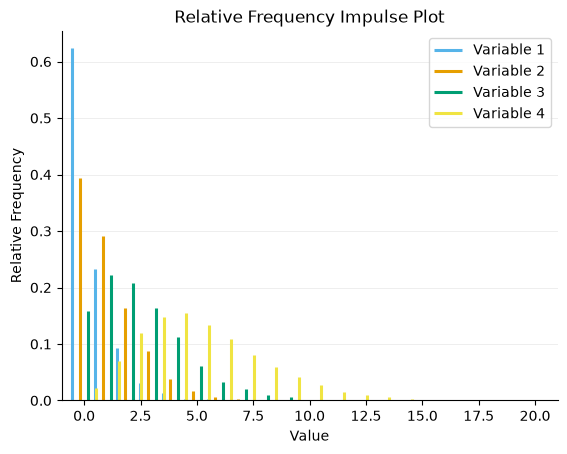

In [10]:
for r in [1, 2, 4, 8]:
    red, green = RV(NegativeMultinomial(r=r, p=[0.3, 0.2]))
    red.sim(10000).plot()

In [11]:
[
    [round(float(m), 2) for m in NegativeMultinomial(r=r, p=[0.3, 0.2]).mean()]
    for r in [1, 2, 4, 8]
]

[[0.6, 0.4], [1.2, 0.8], [2.4, 1.6], [4.8, 3.2]]

## Comparison: one count on its own is a Pascal

Watch a single color and the stopping color, and ignore every other draw. What is left is an ordinary wait for the `r`-th stop, so count `i` is marginally `Pascal(r, p0 / (p0 + p[i]))` -- the number of color-`i` marbles drawn before the `r`-th stopping marble. For the red count here, `p0 = 0.5`, so that is `Pascal(r=3, p=0.5 / 0.8)` = `Pascal(r=3, p=0.625)`.

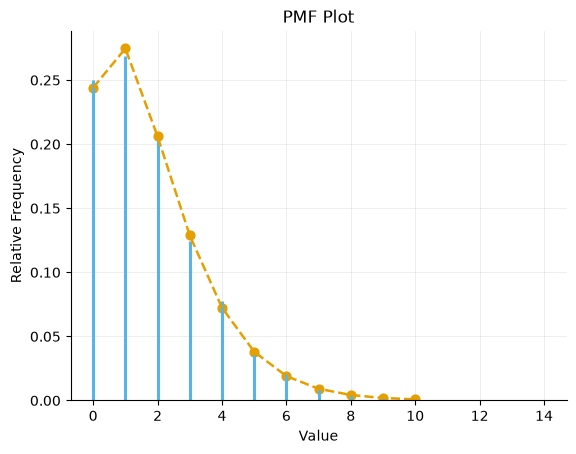

In [12]:
A.sim(10000).plot()
Pascal(r=3, p=0.625).plot()

With only one counted color there is nothing to ignore, and the distribution *is* a Pascal: the single count of `NegativeMultinomial(r, [p])` is exactly `Pascal(r, 1 - p)`.

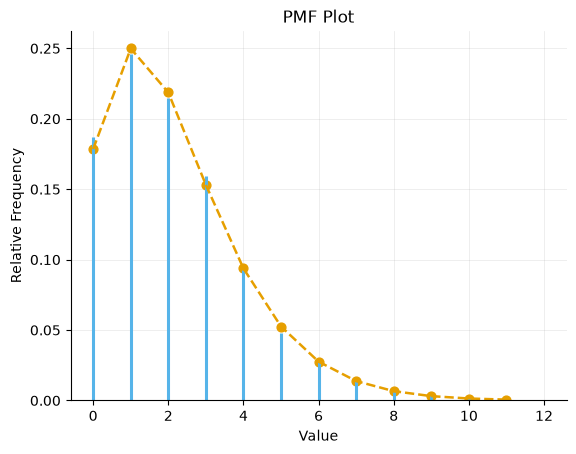

In [13]:
(C,) = RV(NegativeMultinomial(r=4, p=[0.35]))
C.sim(10000).plot()
Pascal(r=4, p=0.65).plot()

## Comparison: the same jar, a different question

`Multinomial` fixes the **number of draws** and asks how many of each color turn up. `NegativeMultinomial` fixes the **number of stopping-color marbles to collect** and asks the same thing, letting the number of draws vary.

That difference flips the sign of the relationship between the counts. With the number of draws free to vary, a run that happens to take a long time inflates every count at once, so the counts rise and fall together -- positively correlated.

In [14]:
(A & B).sim(10000).corr()

np.float64(0.3029331798860118)

In a `Multinomial` the counts have to add up to the fixed number of draws, so a large red count leaves room only for a small green one: the same two counts are negatively correlated.

In [15]:
P, Q, R = RV(Multinomial(n=6, p=[0.3, 0.2, 0.5]))
(P & Q).sim(10000).corr()

np.float64(-0.33227511839211893)

The joint plots show where that comes from. Nothing caps the negative multinomial's counts, so its mass spreads outward along the diagonal: large values of one count turn up alongside large values of the other.

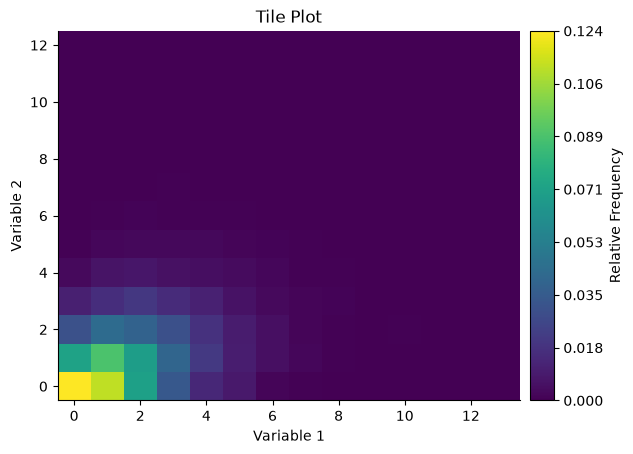

In [16]:
(A & B).sim(10000).plot()

The multinomial version is squeezed into a triangle instead. Every pair of counts has to satisfy `x + y <= 6`, so there is nothing at all past that boundary -- and inside it, a large red count forces a small green one.

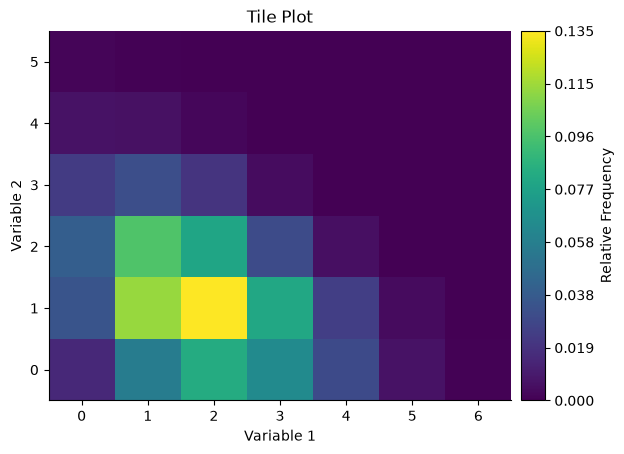

In [17]:
(P & Q).sim(10000).plot()

## Two things to watch out for

**`p` lists only the colors you are counting.** The stopping color's probability is whatever is left over, `1 - sum(p)`, which the distribution stores as `p0`. That is why the entries of `p` have to add up to *less* than 1: if they added up to 1 there would be no chance of ever drawing the stopping color, the experiment would never end, and the counts would grow without limit. Asking for that raises a clear error rather than quietly returning a missing value.

**`r` counts the stopping color, not the draws.** In `Multinomial` the parameter `n` is the number of draws, fixed in advance. Here `r` is how many stopping-color marbles you are waiting for, and the number of draws is however many it takes: `r` plus all of the counts added together.

In [18]:
X.p0

0.5

In [19]:
# The number of draws is r plus every count added together, so unlike a
# multinomial's fixed n it varies from one run to the next.
draws = 3 + A + B
draws.sim(10)

0,7
1,5
2,5
3,3
4,5
5,6
6,12
7,5
8,4
...,...
9,3
